In [1]:
import pandas as pd
import numpy as np
from lifelines import CoxPHFitter, KaplanMeierFitter
from lifelines.utils import concordance_index
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

# Load the FULL commercial dataset — including pending cases
df_full = pd.read_csv(r'C:\Users\Karnaveer Singh\Justice_Hq\data\raw\commercial_clean.csv')

print(f"Shape: {df_full.shape}")
print(f"Columns: {df_full.columns.tolist()}")

Shape: (2203465, 26)
Columns: ['ddl_case_id', 'year', 'state_code', 'dist_code', 'court_no', 'cino', 'judge_position', 'female_defendant', 'female_petitioner', 'female_adv_def', 'female_adv_pet', 'type_name', 'purpose_name', 'disp_name', 'date_of_filing', 'date_of_decision', 'date_first_list', 'date_last_list', 'date_next_list', 'act', 'section', 'bailable_ipc', 'number_sections_ipc', 'criminal', 'resolution_days', 'resolution_bucket']


In [2]:
# Convert dates
df_full['date_of_filing'] = pd.to_datetime(df_full['date_of_filing'], errors='coerce')
df_full['date_of_decision'] = pd.to_datetime(df_full['date_of_decision'], errors='coerce')

# Survival analysis needs two columns:
# duration — how long we observed the case
# event_observed — did it resolve (1) or still pending (0)

# For resolved cases: duration = resolution_days
# For pending cases: duration = days from filing to dataset cutoff (Dec 2018)
DATASET_CUTOFF = pd.Timestamp('2018-12-31')

df_full['duration'] = np.where(
    df_full['date_of_decision'].notna(),
    df_full['resolution_days'],
    (DATASET_CUTOFF - df_full['date_of_filing']).dt.days
)

df_full['event_observed'] = df_full['date_of_decision'].notna().astype(int)

# Drop invalid durations
df_surv = df_full[
    (df_full['duration'] > 0) & 
    (df_full['duration'] <= 10950) &
    (df_full['date_of_filing'].notna())
].copy()

print(f"Survival dataset: {len(df_surv):,}")
print(f"Resolved (event=1): {df_surv['event_observed'].sum():,} ({df_surv['event_observed'].mean()*100:.1f}%)")
print(f"Pending (event=0):  {(df_surv['event_observed']==0).sum():,} ({(df_surv['event_observed']==0).mean()*100:.1f}%)")
print(f"\nDuration stats:")
print(df_surv['duration'].describe())

Survival dataset: 2,203,465
Resolved (event=1): 2,203,465 (100.0%)
Pending (event=0):  0 (0.0%)

Duration stats:
count    2.203465e+06
mean     5.085894e+02
std      5.836915e+02
min      1.000000e+00
25%      7.700000e+01
50%      2.930000e+02
75%      7.310000e+02
max      7.020000e+03
Name: duration, dtype: float64


In [3]:
import glob

case_files = [
    r"C:\Users\Karnaveer Singh\Justice_Hq\csv\cases\cases_2010.csv",
    r"C:\Users\Karnaveer Singh\Justice_Hq\csv\cases\cases_2011.csv",
    r"C:\Users\Karnaveer Singh\Justice_Hq\csv\cases\cases_2012.csv",
    r"C:\Users\Karnaveer Singh\Justice_Hq\csv\cases\cases_2013.csv",
    r"C:\Users\Karnaveer Singh\Justice_Hq\csv\cases\cases_2014.csv",
    r"C:\Users\Karnaveer Singh\Justice_Hq\csv\cases\cases_2015.csv",
]

# Load only 2010-2015, all cases (resolved + pending)
# Only columns we need for survival analysis
cols_needed = ['ddl_case_id', 'year', 'state_code', 'dist_code', 
               'court_no', 'judge_position', 'type_name',
               'date_of_filing', 'date_of_decision']

slices = []
for path in case_files:
    year_label = path.split("_")[-1].replace(".csv", "")
    print(f"Loading {year_label}...")
    chunk = pd.read_csv(path, usecols=cols_needed)
    slices.append(chunk)

df_raw = pd.concat(slices, ignore_index=True)
print(f"\nTotal rows: {len(df_raw):,}")
print(f"With decision date: {df_raw['date_of_decision'].notna().sum():,}")
print(f"Without decision date (pending): {df_raw['date_of_decision'].isna().sum():,}")

Loading 2010...
Loading 2011...
Loading 2012...
Loading 2013...
Loading 2014...
Loading 2015...

Total rows: 42,796,872
With decision date: 35,591,564
Without decision date (pending): 7,205,308


In [4]:
# Load type_clean to filter commercial types
type_clean = pd.read_csv(r'C:\Users\Karnaveer Singh\Justice_Hq\data\lookups\type_clean.csv')
commercial_type_codes = set(type_clean[type_clean['is_commercial']==True]['type_name'].unique())

# Filter to commercial cases
df_raw = df_raw[df_raw['type_name'].isin(commercial_type_codes)].copy()
print(f"Commercial cases: {len(df_raw):,}")
print(f"Resolved: {df_raw['date_of_decision'].notna().sum():,}")
print(f"Pending:  {df_raw['date_of_decision'].isna().sum():,}")

# Convert dates
df_raw['date_of_filing'] = pd.to_datetime(df_raw['date_of_filing'], errors='coerce')
df_raw['date_of_decision'] = pd.to_datetime(df_raw['date_of_decision'], errors='coerce')

# Create survival columns
CUTOFF = pd.Timestamp('2015-12-31')

df_raw['duration'] = np.where(
    df_raw['date_of_decision'].notna(),
    (df_raw['date_of_decision'] - df_raw['date_of_filing']).dt.days,
    (CUTOFF - df_raw['date_of_filing']).dt.days
)

df_raw['event_observed'] = df_raw['date_of_decision'].notna().astype(int)

# Clean
df_surv = df_raw[
    (df_raw['duration'] > 0) &
    (df_raw['duration'] <= 10950) &
    (df_raw['date_of_filing'].notna())
].copy()

print(f"\nSurvival dataset: {len(df_surv):,}")
print(f"Resolved (event=1): {df_surv['event_observed'].sum():,} ({df_surv['event_observed'].mean()*100:.1f}%)")
print(f"Pending  (event=0): {(df_surv['event_observed']==0).sum():,} ({(df_surv['event_observed']==0).mean()*100:.1f}%)")

Commercial cases: 1,090,777
Resolved: 921,208
Pending:  169,569

Survival dataset: 852,234
Resolved (event=1): 683,001 (80.1%)
Pending  (event=0): 169,233 (19.9%)


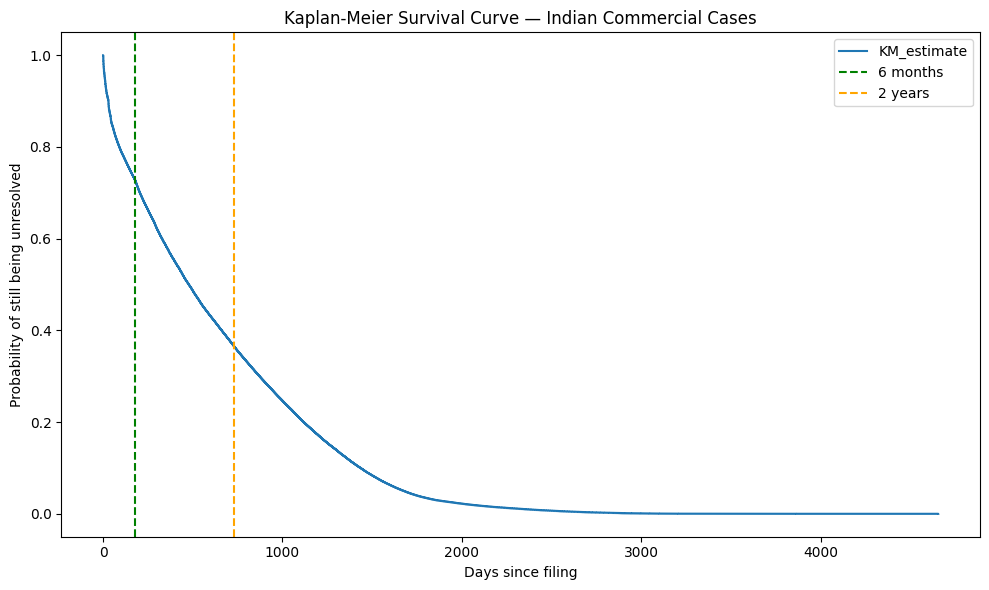

Probability of still being unresolved at:
  6 months (180d):  0.726
  1 year (365d):    0.574
  2 years (730d):   0.365
  3 years (1095d):  0.209

Median survival time: 478 days


In [5]:
# Kaplan-Meier — overall survival curve
kmf = KaplanMeierFitter()
kmf.fit(df_surv['duration'], event_observed=df_surv['event_observed'])

plt.figure(figsize=(10, 6))
kmf.plot_survival_function()
plt.title('Kaplan-Meier Survival Curve — Indian Commercial Cases')
plt.xlabel('Days since filing')
plt.ylabel('Probability of still being unresolved')
plt.axvline(x=180, color='green', linestyle='--', label='6 months')
plt.axvline(x=730, color='orange', linestyle='--', label='2 years')
plt.legend()
plt.tight_layout()
plt.savefig(r'C:\Users\Karnaveer Singh\Justice_Hq\notebooks\km_curve.png')
plt.show()

# Key milestones
print("Probability of still being unresolved at:")
print(f"  6 months (180d):  {kmf.survival_function_at_times([180]).values[0]:.3f}")
print(f"  1 year (365d):    {kmf.survival_function_at_times([365]).values[0]:.3f}")
print(f"  2 years (730d):   {kmf.survival_function_at_times([730]).values[0]:.3f}")
print(f"  3 years (1095d):  {kmf.survival_function_at_times([1095]).values[0]:.3f}")
print(f"\nMedian survival time: {kmf.median_survival_time_:.0f} days")

## Day 5 Finding — Kaplan-Meier Survival Analysis

Median survival time: 478 days (1.3 years)
- 72.6% of commercial cases still unresolved at 6 months
- 57.4% still unresolved at 1 year
- 36.5% still unresolved at 2 years

This accounts for censored cases (pending) that XGBoost ignored.
The true median is 478 days vs 305 days from naive calculation —
censoring correction adds 173 days to the median estimate.

In [6]:
from sklearn.preprocessing import LabelEncoder

# Prepare features for Cox model
cox_df = df_surv[['duration', 'event_observed', 'state_code', 
                   'dist_code', 'court_no', 'judge_position', 
                   'type_name', 'year']].copy()

# Encode categoricals
for col in ['state_code', 'dist_code', 'court_no', 'judge_position', 'type_name']:
    le = LabelEncoder()
    cox_df[col] = le.fit_transform(cox_df[col].astype(str))

# Cox model — sample 100k rows for speed
cox_sample = cox_df.sample(100000, random_state=42)

cph = CoxPHFitter(penalizer=0.1)
cph.fit(cox_sample, duration_col='duration', event_col='event_observed')

print(cph.summary[['coef', 'exp(coef)', 'p']].round(4))
print(f"\nConcordance index: {cph.concordance_index_:.4f}")

                  coef  exp(coef)       p
covariate                                
state_code      0.0078     1.0078  0.0000
dist_code       0.0004     1.0004  0.0637
court_no       -0.0059     0.9941  0.0000
judge_position -0.0002     0.9998  0.0386
type_name       0.0184     1.0186  0.0000
year            0.0628     1.0648  0.0000

Concordance index: 0.6260


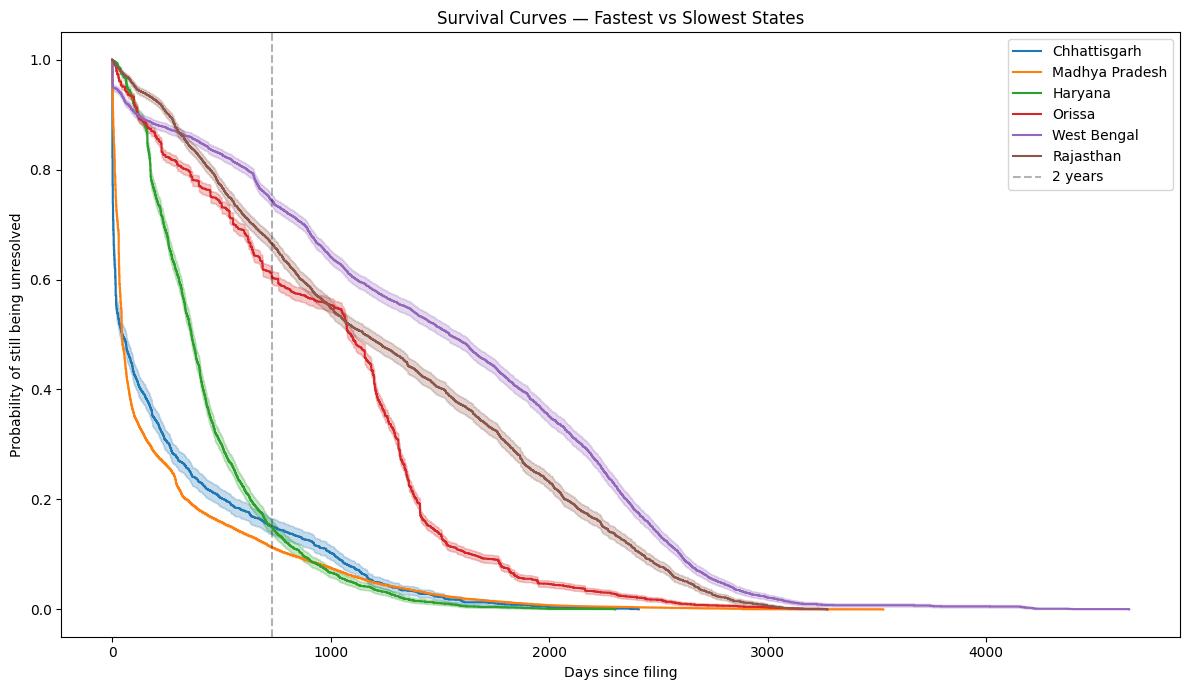

In [7]:
# KM curves for fastest vs slowest states
fig, ax = plt.subplots(figsize=(12, 7))

# Top 3 fastest and slowest states by median resolution
state_medians = df_surv.groupby('state_code')['duration'].median()
state_medians = state_medians[df_surv.groupby('state_code')['duration'].count() > 1000]

fastest = state_medians.nsmallest(3).index.tolist()
slowest = state_medians.nlargest(3).index.tolist()

# Load state names
state_key = pd.read_csv(r'C:\Users\Karnaveer Singh\Justice_Hq\csv\keys\cases_state_key.csv')
state_map = dict(zip(state_key['state_code'], state_key['state_name']))

for state in fastest + slowest:
    mask = df_surv['state_code'] == state
    kmf = KaplanMeierFitter()
    kmf.fit(df_surv[mask]['duration'], 
            event_observed=df_surv[mask]['event_observed'],
            label=f"{state_map.get(state, state)}")
    kmf.plot_survival_function(ax=ax)

ax.set_title('Survival Curves — Fastest vs Slowest States')
ax.set_xlabel('Days since filing')
ax.set_ylabel('Probability of still being unresolved')
ax.axvline(x=730, color='black', linestyle='--', alpha=0.3, label='2 years')
plt.legend()
plt.tight_layout()
plt.savefig(r'C:\Users\Karnaveer Singh\Justice_Hq\notebooks\km_by_state.png')
plt.show()

## Day 5 Finding — Jurisdictional Survival Curves

Haryana resolves 90%+ of commercial cases within 2 years.
Orissa still has 60% unresolved at 2 years.
West Bengal cases drag past 3000 days (8+ years).

The step pattern in Orissa suggests batch court disposals —
likely administrative clearance drives, not organic resolution.

This chart IS the JusticeIQ value proposition:
filing in Haryana vs Orissa is a fundamentally different 
legal risk for a corporate client.

In [8]:
import joblib

joblib.dump(cph, r'C:\Users\Karnaveer Singh\Justice_Hq\models\cox_model.pkl')
joblib.dump(kmf, r'C:\Users\Karnaveer Singh\Justice_Hq\models\km_overall.pkl')

# Save the survival chart
print("Models saved.")
print("\nDay 5 Summary:")
print(f"KM median survival: 478 days (1.3 years)")
print(f"Cox concordance index: 0.626")
print(f"Key finding: Haryana resolves 90%+ within 2 years, Orissa still 60% unresolved at 2 years")

Models saved.

Day 5 Summary:
KM median survival: 478 days (1.3 years)
Cox concordance index: 0.626
Key finding: Haryana resolves 90%+ within 2 years, Orissa still 60% unresolved at 2 years
